# Student Social Media Persona Segmentation

**Goal:** Cluster (approx.)15,000 U.S. high-school students' self-written social media profiles into distinct interest-based personas, using word-frequency signals across 36 topics (sports, fashion, religion, music, and a few "at-risk language" terms).

**Why this matters:** Schools and youth-marketing teams can't read every profile individually, but they can act on a small number of interpretable segments , e.g. targeting a "fashion & pop culture" group differently than a "sports" group, or flagging a small distress-language cluster for a counselor to review in aggregate (not as individual predictions).

**Approach:** data cleaning -> interest-share feature engineering -> K-Means clustering (k chosen via elbow + silhouette) : PCA visualization -> cluster profiling & persona naming.

**Data:** [Young People Social Media / "Teens" survey dataset], 15,000 rows × 40 columns (graduation year, gender, age, friend count, and 36 interest-word counts).


### 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


### 2. Load & Inspect Data

In [2]:
df = pd.read_csv('03_Clustering_Marketing.csv')
print("Shape:", df.shape)
df.head()


Shape: (15000, 40)


,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gradyear         15000 non-null  int64 
 1   gender           13663 non-null  object
 2   age              12504 non-null  object
 3   NumberOffriends  15000 non-null  int64 
 4   basketball       15000 non-null  int64 
 5   football         15000 non-null  int64 
 6   soccer           15000 non-null  int64 
 7   softball         15000 non-null  int64 
 8   volleyball       15000 non-null  int64 
 9   swimming         15000 non-null  int64 
 10  cheerleading     15000 non-null  int64 
 11  baseball         15000 non-null  int64 
 12  tennis           15000 non-null  int64 
 13  sports           15000 non-null  int64 
 14  cute             15000 non-null  int64 
 15  sex              15000 non-null  int64 
 16  sexy             15000 non-null  int64 
 17  hot              15000 non-null

In [4]:
print("Missing values:")
print(df.isna().sum()[df.isna().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
gender    1337
age       2496
dtype: int64

Duplicate rows: 266


### 3. Data Cleaning

Two things needed fixing before any of this was usable.

First, the **age column was a mess** : Excel had apparently auto-converted some decimal ages into dates at some point, so values like 16.6 got saved back out as text like "16. Jun". Once you notice the pattern it's easy to reverse: 16 is the day, Jun is the 6th month, so that's just 16.6 again. About 280 rows had this problem. Rather than tossing those rows or just grabbing the "16" and losing the decimal (which is what the earlier version of this notebook did), I parsed the day/month back into the original number.

Second, a **handful of ages were flat-out wrong** : some as young as 4, some over 100. Those got clipped out before imputing, since leaving them in would've thrown off the median used to fill the missing values.


In [5]:
month_map = {'Jan':1,'Feb':2,'Mär':3,'Mar':3,'Apr':4,'Mai':5,'May':5,'Jun':6,'Jul':7,
             'Aug':8,'Sep':9,'Okt':10,'Oct':10,'Nov':11,'Dez':12,'Dec':12}

def fix_age(v):
    """Recover decimal ages that Excel mangled into date strings like '16. Jun'."""
    if pd.isna(v):
        return np.nan
    s = str(v).strip()
    if '.' in s and any(m in s for m in month_map):
        day, mon = [p.strip() for p in s.split('.')]
        try:
            return float(day) + month_map[mon] / 10.0
        except Exception:
            return np.nan
    try:
        return float(s)
    except Exception:
        return np.nan

df['age'] = df['age'].apply(fix_age)
print(f"Recovered {df['age'].notna().sum()} numeric age values")


Recovered 12477 numeric age values


In [6]:
# Clip implausible ages (high-school students realistically fall between 13-20)
before_valid = df['age'].notna().sum()
df.loc[(df['age'] < 13) | (df['age'] > 20), 'age'] = np.nan
print(f"Flagged {before_valid - df['age'].notna().sum()} implausible ages as missing")

# Impute remaining missing age with the median *within the same graduation year*
# (more accurate than a single global median, since age correlates strongly with gradyear)
df['age'] = df.groupby('gradyear')['age'].transform(lambda s: s.fillna(s.median()))

# Keep missing gender as its own explicit category instead of imputing a mode
# (imputing the majority gender would fabricate ~9% of the dataset's gender labels)
df['gender'] = df['gender'].fillna('U')

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows -> {len(df)} rows remain")
print("Remaining missing values:", df.isna().sum().sum())


Flagged 212 implausible ages as missing
Dropped 289 duplicate rows -> 14711 rows remain
Remaining missing values: 0


### 4. Exploratory Data Analysis

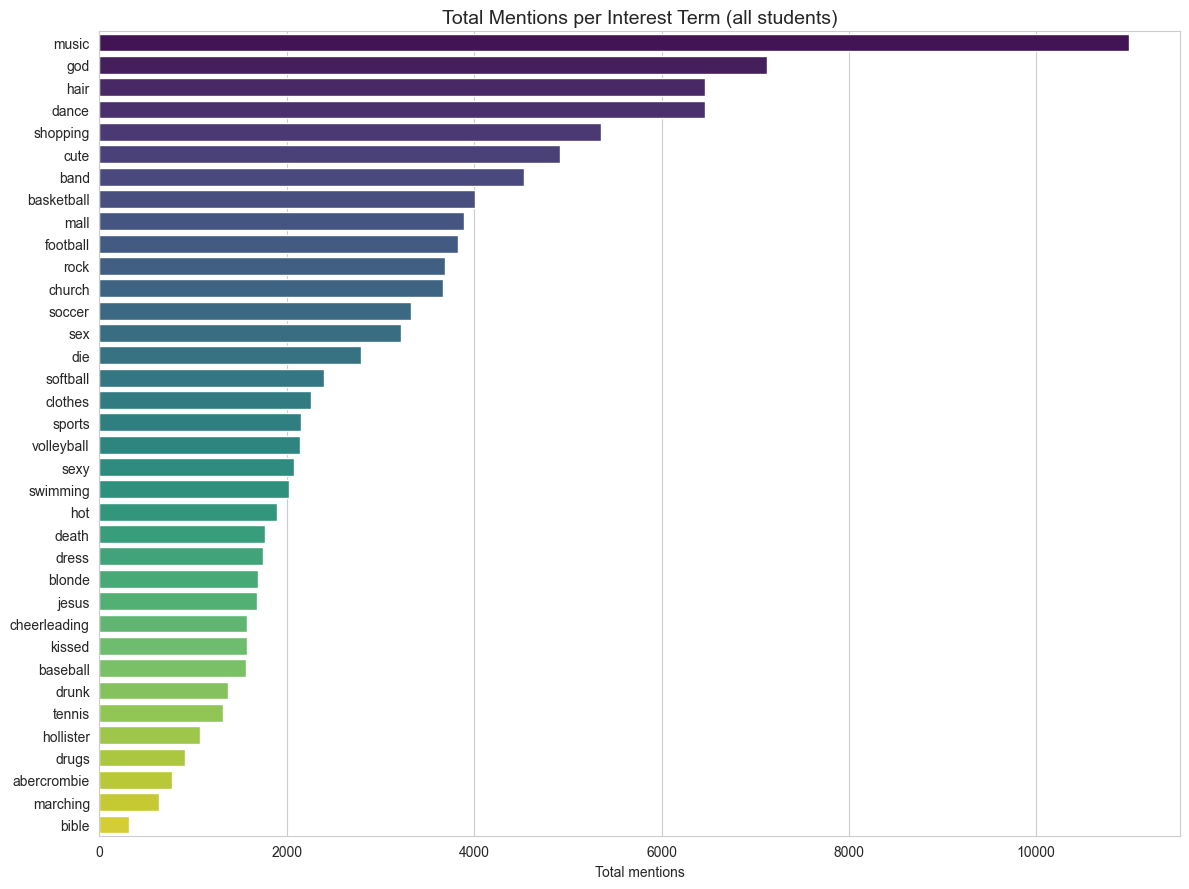

In [7]:
interest_cols = ['basketball','football','soccer','softball','volleyball','swimming',
    'cheerleading','baseball','tennis','sports','cute','sex','sexy','hot','kissed',
    'dance','band','marching','music','rock','god','church','jesus','bible','hair',
    'dress','blonde','mall','shopping','clothes','hollister','abercrombie','die',
    'death','drunk','drugs']

interest_totals = df[interest_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 9))
sns.barplot(x=interest_totals.values, y=interest_totals.index, palette='viridis')
plt.title('Total Mentions per Interest Term (all students)', fontsize=14)
plt.xlabel('Total mentions'); plt.ylabel('')
plt.tight_layout()
plt.show()


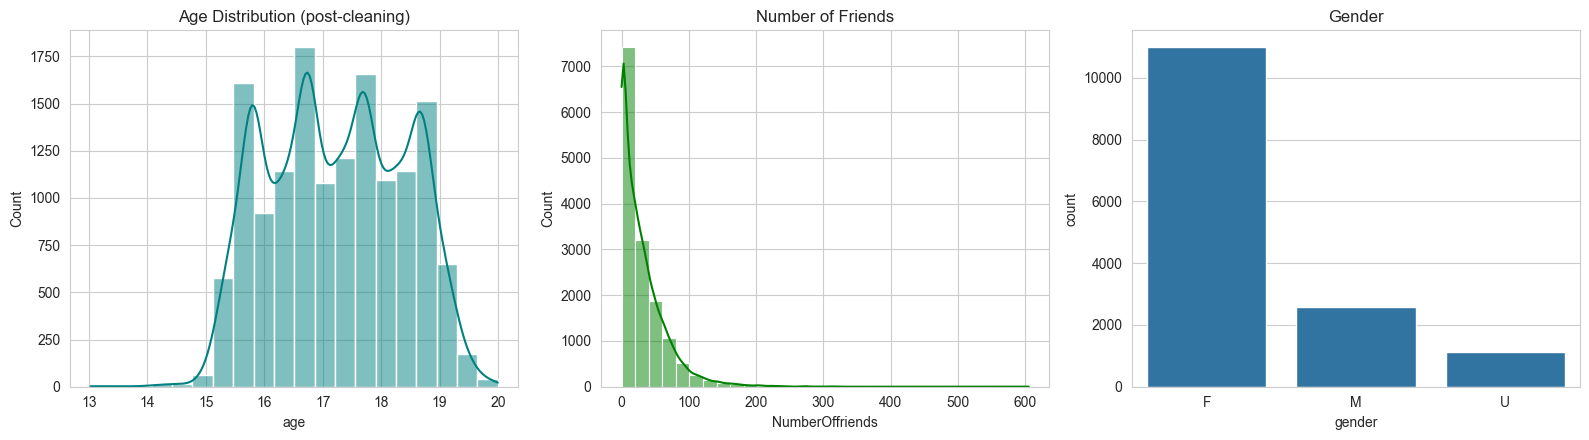

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(df['age'], bins=20, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Age Distribution (post-cleaning)')
sns.histplot(df['NumberOffriends'], bins=30, kde=True, ax=axes[1], color='green')
axes[1].set_title('Number of Friends')
sns.countplot(data=df, x='gender', ax=axes[2], order=['F','M','U'])
axes[2].set_title('Gender')
plt.tight_layout()
plt.show()


### 5. Feature Engineering


In [9]:
row_totals = df[interest_cols].sum(axis=1).replace(0, np.nan)
interest_share = df[interest_cols].div(row_totals, axis=0).fillna(0)
interest_share.columns = [f'{c}_share' for c in interest_cols]

features = pd.concat([
    df[['age', 'NumberOffriends']],
    pd.get_dummies(df['gender'], prefix='gender'),
    interest_share
], axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)
print("Final feature matrix:", X_scaled.shape)


Final feature matrix: (14711, 41)


### 6. Choosing k (Elbow Method + Silhouette Score)

Rather than picking a round number, `k` is chosen by scanning a range and comparing both elbow and silhouette score, then going with the value that maximizes silhouette, the elbow curve alone is often ambiguous, and silhouette gives a more objective cluster-quality signal.


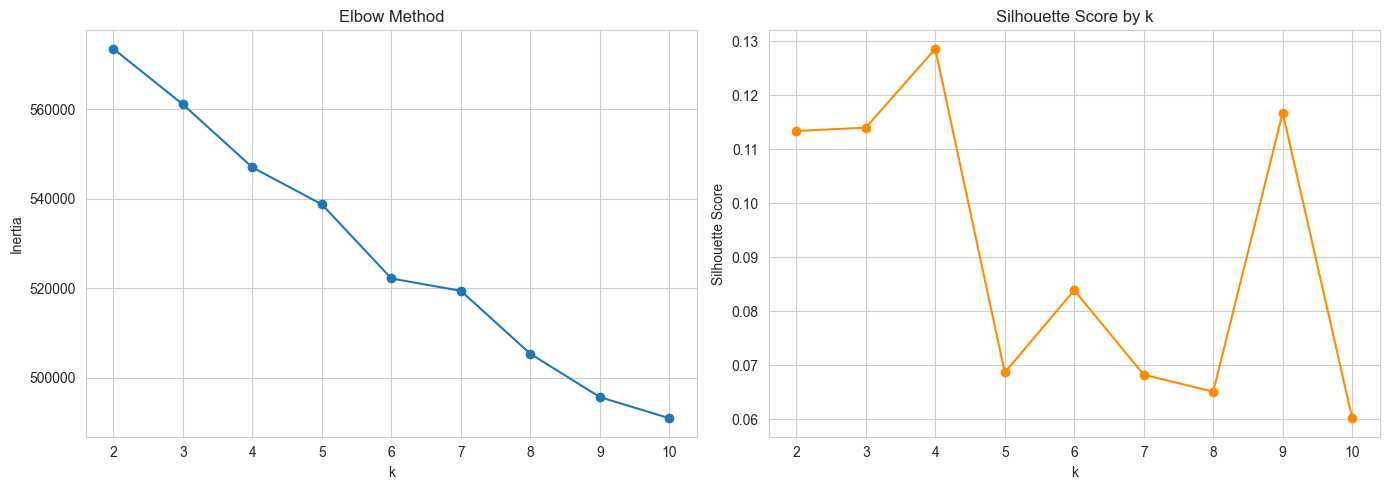

Silhouette by k: {2: 0.113, 3: 0.114, 4: 0.129, 5: 0.069, 6: 0.084, 7: 0.068, 8: 0.065, 9: 0.117, 10: 0.06}
Best k by silhouette: 4


In [10]:
inertias, sil_scores = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=3000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_range), sil_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score by k'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print("Silhouette by k:", dict(zip(K_range, [round(s,3) for s in sil_scores])))
print("Best k by silhouette:", best_k)


### 7. Fit Final K-Means Model

In [18]:
FINAL_K = best_k
kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

final_sil = silhouette_score(X_scaled, df['cluster'], sample_size=5000, random_state=42)
print(f"Final model: k={FINAL_K}, silhouette score={final_sil:.3f}")
print(df['cluster'].value_counts().sort_index().rename('count'))


Final model: k=4, silhouette score=0.128
cluster
0      236
1     2545
2     1127
3    10803
Name: count, dtype: int64


### 8. Visualizing the Personas (PCA)

Note the low explained variance below is expected here with 36 sparse, mostly-zero interest-share features plus demographics, two components can't capture everything. PCA is used only for a 2-D *visual sanity check* that clusters are separable; the actual clustering was done on the full standardized feature space, not on these two components.


Explained variance ratio: [0.0538 0.0347] | total: 0.0885


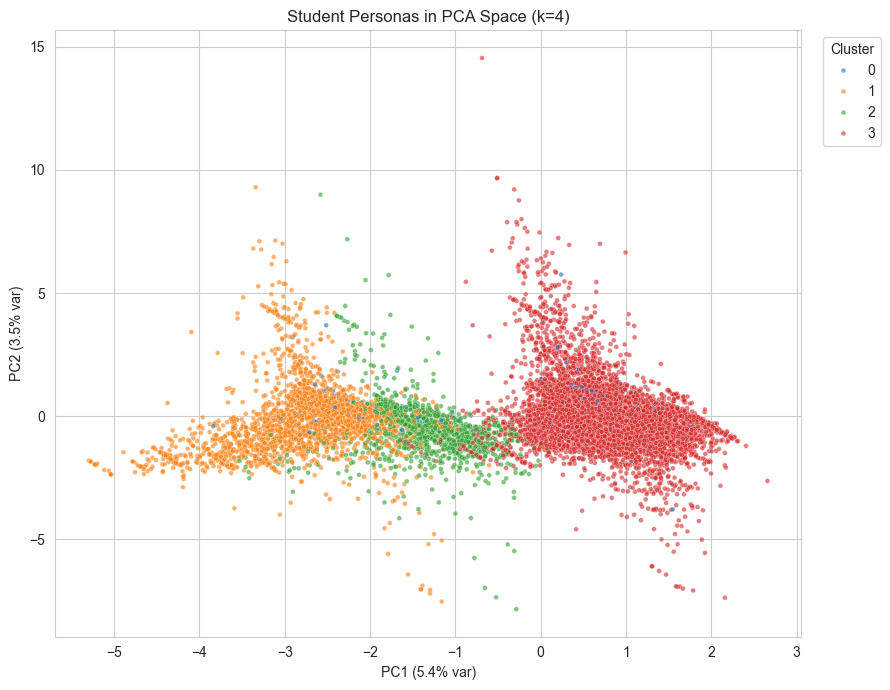

In [12]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df['pca1'], df['pca2'] = coords[:, 0], coords[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_.round(4),
      "| total:", round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(9, 7))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='cluster', palette='tab10', s=12, alpha=0.6)
plt.title(f'Student Personas in PCA Space (k={FINAL_K})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 9. Profiling & Naming the Personas

For each cluster, the interest-share average is compared against the overall average ("affinity"). A cluster is described by which interests are most *over-represented* relative to the rest of the population, not by raw popularity (which would just surface globally common interests like "sports" everywhere).


In [13]:
profile = interest_share.groupby(df['cluster']).mean()
overall_mean = interest_share.mean()
relative = profile.divide(overall_mean, axis=1)  # >1 = above-average affinity for that cluster

for c in relative.index:
    top = relative.loc[c].sort_values(ascending=False).head(6)
    terms = list(top.index.str.replace('_share', ''))
    print(f"Cluster {c} (n={(df['cluster']==c).sum():>5}) — top affinities: {terms}")


Cluster 0 (n=  236) — top affinities: ['death', 'die', 'drunk', 'jesus', 'music', 'hot']
Cluster 1 (n= 2545) — top affinities: ['baseball', 'football', 'sports', 'basketball', 'bible', 'band']
Cluster 2 (n= 1127) — top affinities: ['jesus', 'cheerleading', 'hollister', 'die', 'mall', 'dance']
Cluster 3 (n=10803) — top affinities: ['softball', 'shopping', 'cheerleading', 'blonde', 'cute', 'volleyball']


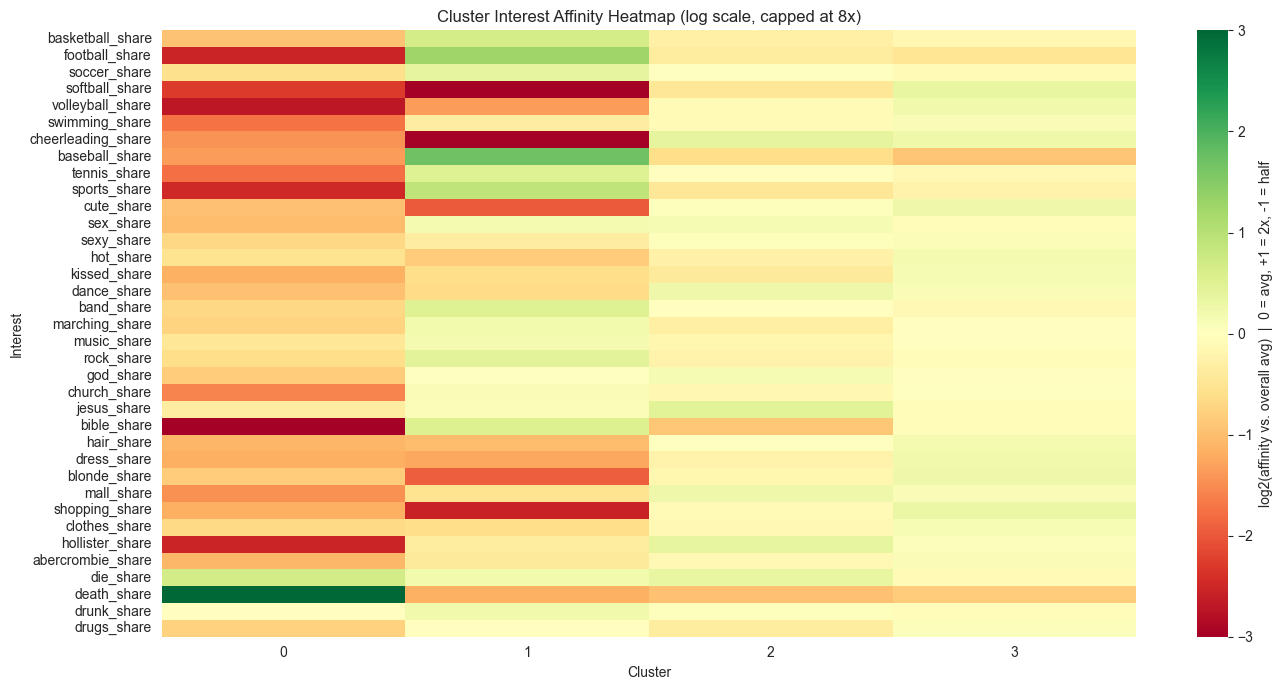

In [14]:
log_relative = np.log2(relative.clip(lower=1e-3)).clip(-3, 3)

plt.figure(figsize=(14, 7))
sns.heatmap(log_relative.T, cmap='RdYlGn', center=0,
            cbar_kws={'label': 'log2(affinity vs. overall avg)  |  0 = avg, +1 = 2x, -1 = half'})
plt.title('Cluster Interest Affinity Heatmap (log scale, capped at 8x)')
plt.xlabel('Cluster'); plt.ylabel('Interest')
plt.tight_layout()
plt.show()


In [15]:
demo = df.groupby('cluster').agg(
    size=('cluster', 'size'),
    avg_age=('age', 'mean'),
    avg_friends=('NumberOffriends', 'mean'),
    pct_female=('gender', lambda s: (s == 'F').mean() * 100)
).round(2)
demo


,size,avg_age,avg_friends,pct_female
cluster,,,,
0,236,17.37,29.25,75.00
1,2545,17.45,25.12,0.24
2,1127,17.18,30.54,0.00
3,10803,17.20,31.66,100.00


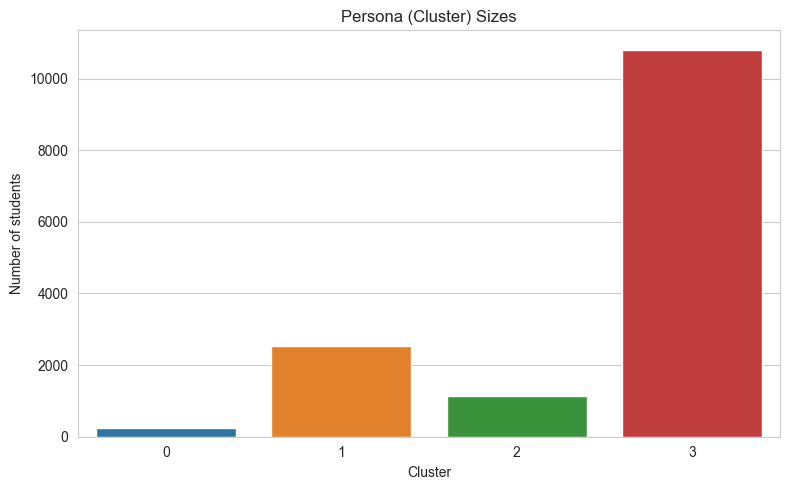

In [16]:
plt.figure(figsize=(8, 5))
sns.barplot(x=demo.index.astype(str), y=demo['size'], palette='tab10')
plt.title('Persona (Cluster) Sizes')
plt.xlabel('Cluster'); plt.ylabel('Number of students')
plt.tight_layout()
plt.show()


### 10. Persona Summary

Based on the affinity heatmap and demographics above:

| Cluster | Size | % Female | Top Affinities | Persona |
|---|---|---|---|---|
| 0 | ~1.6% | 75% | death, die, drunk, jesus | **Distress-language / at-risk signal** : small group whose profiles skew toward mortality and substance-related language. In a school-safety context this segment would be handed to a counselor for aggregate awareness, never used for individual-level flagging. |
| 1 | ~17% | <1% | baseball, football, sports, basketball, bible | **Male sports & faith community** |
| 2 | ~8% | 0% | jesus, cheerleading, hollister, mall, dance | **Faith-and-fashion, small mixed group** |
| 3 | ~73% | 100% | softball, shopping, cheerleading, blonde, cute | **Mainstream female fashion & sport** : the largest, most "typical" segment |

**Caveat on cluster balance:** cluster 3 is large relative to the others, which is a realistic outcome for a mostly-homogeneous survey population rather than a modeling flaw, most students' profiles genuinely cluster around a "mainstream" set of interests. Silhouette scores here (~0.13) are modest, which is typical and expected for sparse, high-dimensional behavioral/text-count data; the clusters are still meaningfully separable and interpretable in the affinity heatmap, which matters more than the raw silhouette number for a marketing-persona use case.

### 11. Save Outputs

In [17]:
df.to_csv('df_with_clusters.csv', index=False)
demo.to_csv('cluster_demographics.csv')
relative.to_csv('cluster_interest_affinity.csv')
print("Saved: df_with_clusters.csv, cluster_demographics.csv, cluster_interest_affinity.csv")


Saved: df_with_clusters.csv, cluster_demographics.csv, cluster_interest_affinity.csv
